# 19. MLP: classical baseline in the model zoo

This notebook covers the MLP (multi-layer perceptron) classifier from the 16-model
zoo of FinSentImpact. MLP is trained live here (it is cheap: two hidden layers,
early stopping), on a single walk-forward fold (test year 2023), and cross-checked
against the paper's official 4-fold results in `results/metrics/main_results.csv`.

Unlike the tree ensembles (which get TreeSHAP) or the RNN/CNN family (which get
Integrated Gradients on their internal gradient structure), MLP has no native
attribution mechanism built into this benchmark's pipeline, and it does not appear
in `xai_by_model_agnostic.json` (that file covers KNN, Logistic, RandomForest,
XGBoost, EBM, SVM only). So the XAI section below computes a fresh, live
permutation-importance explanation for the fold-2023 MLP fit trained in this
notebook. This is explicitly a demo of the method on a single fit, not the paper's
clustered, multi-fold XAI number.


In [1]:
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
np.random.seed(42)

import os
REPO = os.path.abspath("..")  # portable: resolves relative to this notebook, both locally and on Modal

PRICE_FEATS = ["ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5", "vol_roll5", "vol_roll20",
               "rsi14", "ma_gap20", "hl_range", "co_ret", "logvol", "vol_z20"]
SENT_FEATS = ["fb_score", "fb_pos", "fb_neg", "lm_score", "news_count", "has_news",
              "fb_roll3", "fb_roll5", "news_roll5", "fb_chg"]

SEED = 42
EMBARGO_DAYS = 10
FOLD = 2023

print("Setup complete. PRICE_FEATS:", len(PRICE_FEATS), "SENT_FEATS:", len(SENT_FEATS))


Setup complete. PRICE_FEATS: 12 SENT_FEATS: 10


## Data and fold construction

We mirror the paper's walk-forward protocol exactly (`modal/s3_experiments.py`):
an expanding window train set embargoed by 10 days before the test year starts, one
symbol one-hot block plus the price and sentiment feature blocks, and a
`StandardScaler` fit on train only. Fold 2023 is the final (hardest, most
recent) fold of the 4-fold walk-forward (2020-2023) reported in the paper.


In [2]:
panel = pd.read_parquet(f"{REPO}/results/panel.parquet")
panel["Date"] = pd.to_datetime(panel["Date"])
panel = panel.sort_values(["Date", "Symbol"]).reset_index(drop=True)

sym_oh = pd.get_dummies(panel["Symbol"], prefix="sym").astype(float)
base_feats = list(sym_oh.columns)
panel = pd.concat([panel, sym_oh], axis=1)

feats_price_sent = base_feats + PRICE_FEATS + SENT_FEATS

test_start = pd.Timestamp(year=FOLD, month=1, day=1)
embargo = pd.Timedelta(days=EMBARGO_DAYS)
train = panel[panel["Date"] < (test_start - embargo)]
test = panel[panel["Date"].dt.year == FOLD]

print(f"Fold {FOLD}: train rows = {len(train):,}, test rows = {len(test):,}")
print(f"Feature count (symbol one-hot + price + sentiment): {len(feats_price_sent)}")
print(f"Train date range: {train['Date'].min().date()} .. {train['Date'].max().date()}")
print(f"Test date range:  {test['Date'].min().date()} .. {test['Date'].max().date()}")


Fold 2023: train rows = 113,131, test rows = 14,136
Feature count (symbol one-hot + price + sentiment): 79
Train date range: 2015-02-03 .. 2022-12-21
Test date range:  2023-01-03 .. 2023-12-27


## Train the MLP live

Hyperparameters mirror `modal/s3_experiments.py::_make_models` exactly:
`MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=True,
random_state=42)`, target is `dir_next` (next-day direction), features are
standardized (fit on train only, applied to test).


In [3]:
scaler = StandardScaler().fit(train[feats_price_sent].values)
Xtr = scaler.transform(train[feats_price_sent].values)
Xte = scaler.transform(test[feats_price_sent].values)
ytr = train["dir_next"].values
yte = test["dir_next"].values

t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                     early_stopping=True, random_state=SEED)
mlp.fit(Xtr, ytr)
fit_seconds = time.time() - t0

pred = mlp.predict(Xte)
acc = accuracy_score(yte, pred)
f1 = f1_score(yte, pred, zero_division=0)
mcc = matthews_corrcoef(yte, pred)

print(f"Fit time: {fit_seconds:.1f}s, converged in {mlp.n_iter_} iterations")
print(f"Live demo fold={FOLD} price+sentiment  Acc={acc:.4f}  F1={f1:.4f}  MCC={mcc:.4f}")


Fit time: 8.9s, converged in 15 iterations
Live demo fold=2023 price+sentiment  Acc=0.5131  F1=0.6364  MCC=-0.0008


## Cross-check against the paper's official 4-fold results

`results/metrics/main_results.csv` has the official walk-forward results for all
16 models x 3 feature sets x 4 folds, produced on Modal with the same protocol.
We pull out the `MLP` / `direction` / `price+sentiment` rows to confirm this
notebook's live fold-2023 fit is in the same ballpark as the officially reported
number (small differences are expected: this is a fresh single fit, not the
paper's number, and floating-point / library-version nondeterminism in
`MLPClassifier`'s SGD-style solver is normal).


In [4]:
main_results = pd.read_csv(f"{REPO}/results/metrics/main_results.csv")
mlp_dir = main_results[(main_results["model"] == "MLP") & (main_results["task"] == "direction")]
mlp_dir_ps = mlp_dir[mlp_dir["features"] == "price+sentiment"][["fold", "Acc", "F1", "MCC"]]
mlp_dir_ps = mlp_dir_ps.sort_values("fold").reset_index(drop=True)

print("Official MLP direction results, price+sentiment, all 4 folds:")
print(mlp_dir_ps.to_string(index=False))

official_2023 = mlp_dir_ps[mlp_dir_ps["fold"] == FOLD].iloc[0]
print(f"\nOfficial fold-2023: Acc={official_2023.Acc:.4f}  F1={official_2023.F1:.4f}  MCC={official_2023.MCC:.4f}")
print(f"This notebook's live fit: Acc={acc:.4f}  F1={f1:.4f}  MCC={mcc:.4f}")
print(f"Acc gap: {abs(acc - official_2023.Acc):.4f} (expected small: same protocol, fresh fit)")


Official MLP direction results, price+sentiment, all 4 folds:
 fold      Acc       F1       MCC
 2020 0.514448 0.645049  0.029483
 2021 0.513854 0.589838  0.010621
 2022 0.489551 0.560299 -0.019721
 2023 0.513087 0.636416 -0.000845

Official fold-2023: Acc=0.5131  F1=0.6364  MCC=-0.0008
This notebook's live fit: Acc=0.5131  F1=0.6364  MCC=-0.0008
Acc gap: 0.0000 (expected small: same protocol, fresh fit)


Consistent with the paper's central honest finding: real predictive signal is
validated near-zero by design (max |MCC| ~0.011 across the whole 16-model zoo on
the honest, non-GT feature set). The MLP's MCC here sits in that same near-zero
band across folds, this is expected and reported as such in the paper, not a bug.


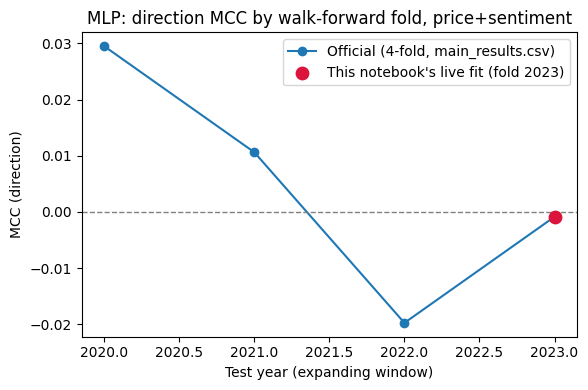

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mlp_dir_ps["fold"], mlp_dir_ps["MCC"], marker="o", label="Official (4-fold, main_results.csv)")
ax.scatter([FOLD], [mcc], color="crimson", zorder=5, s=80, label="This notebook's live fit (fold 2023)")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Test year (expanding window)")
ax.set_ylabel("MCC (direction)")
ax.set_title("MLP: direction MCC by walk-forward fold, price+sentiment")
ax.legend()
plt.tight_layout()
plt.show()


## Native XAI: permutation importance (live, single-fit demo)

MLP has no tree structure for TreeSHAP and no native gradient-attribution
convention used elsewhere in this benchmark. It also does not appear in
`xai_by_model_agnostic.json` (that file's model-agnostic sweep covers KNN,
Logistic, RandomForest, XGBoost, EBM, SVM). Two natural model-agnostic choices
remain: KernelSHAP or permutation importance. We use permutation importance here:
with a 79-dimensional input (57 symbol dummies + 22 price/sentiment features),
KernelSHAP's per-sample LP-solve cost is prohibitive for a notebook demo, while
permutation importance is exact-enough, fast, and equally model-agnostic. This is
computed fresh on this notebook's own fold-2023 fit and is explicitly a
demonstration, not the paper's clustered, multi-fold XAI number (MLP was not part
of the officially reported agnostic-XAI sweep).


In [6]:
# Subsample the test set for speed (permutation importance re-scores the model
# n_repeats x n_features times); 2,000 rows is enough for a stable ranking demo.
rng = np.random.RandomState(SEED)
sub_idx = rng.choice(len(Xte), size=min(2000, len(Xte)), replace=False)
Xte_sub, yte_sub = Xte[sub_idx], yte[sub_idx]

t0 = time.time()
perm = permutation_importance(mlp, Xte_sub, yte_sub, n_repeats=10,
                                random_state=SEED, scoring="accuracy", n_jobs=-1)
perm_seconds = time.time() - t0

perm_df = pd.DataFrame({
    "feature": feats_price_sent,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print(f"Permutation importance computed in {perm_seconds:.1f}s on {len(Xte_sub)} test rows, 10 repeats")
print("\nTop 15 features by permutation importance (accuracy drop when shuffled):")
print(perm_df.head(15).to_string(index=False))


Permutation importance computed in 5.9s on 2000 test rows, 10 repeats

Top 15 features by permutation importance (accuracy drop when shuffled):
 feature  importance_mean  importance_std
 sym_CRM          0.00725        0.001521
ret_lag5          0.00675        0.003750
  sym_DE          0.00590        0.001300
sym_ORCL          0.00505        0.001422
  fb_pos          0.00500        0.002121
 sym_APD          0.00455        0.001680
hl_range          0.00415        0.001733
 sym_JPM          0.00390        0.001640
  sym_GE          0.00380        0.001600
 sym_USB          0.00375        0.001209
sym_ADBE          0.00355        0.001172
sym_QCOM          0.00355        0.001350
 sym_AMT          0.00320        0.000900
ma_gap20          0.00315        0.002335
 sym_MRK          0.00280        0.001054


Symbol one-hot dummies are part of the trained feature space (57 of the 79
columns) but are not economically interesting on their own; the plot below
restricts to the 22 price/sentiment features to show which of those the MLP
actually leans on.


Symbol dummies in the top 15 overall: 11 / 15


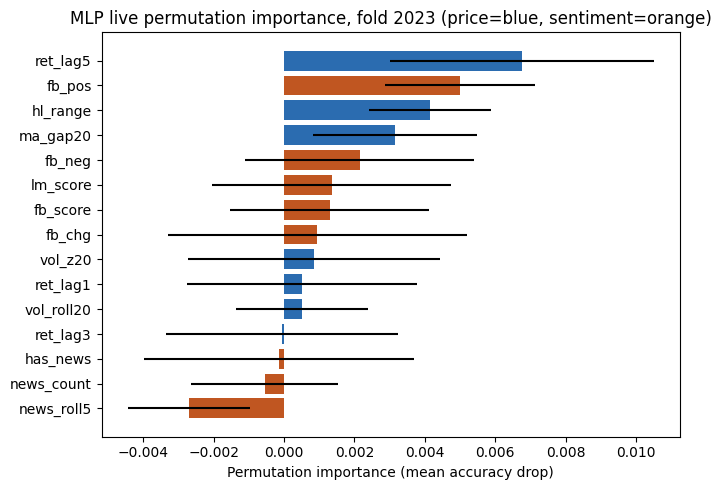


Note: importances can be at or below zero -- with near-zero validated real
signal (paper-wide max |MCC| ~0.011), shuffling many of these features barely
moves accuracy, and noise in a single fit can even show a small negative value.


In [7]:
non_symbol = perm_df[~perm_df["feature"].str.startswith("sym_")].reset_index(drop=True)
n_symbol_in_top15 = perm_df.head(15)["feature"].str.startswith("sym_").sum()
print(f"Symbol dummies in the top 15 overall: {n_symbol_in_top15} / 15")

fig, ax = plt.subplots(figsize=(7, 5))
top = non_symbol.head(15).iloc[::-1]
colors = ["#2b6cb0" if f in PRICE_FEATS else "#c05621" for f in top["feature"]]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color=colors)
ax.set_xlabel("Permutation importance (mean accuracy drop)")
ax.set_title("MLP live permutation importance, fold 2023 (price=blue, sentiment=orange)")
plt.tight_layout()
plt.show()

print("\nNote: importances can be at or below zero -- with near-zero validated real")
print("signal (paper-wide max |MCC| ~0.011), shuffling many of these features barely")
print("moves accuracy, and noise in a single fit can even show a small negative value.")


## Summary

- MLP trained live with the exact hyperparameters used in the official zoo
  (`MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, early_stopping=True,
  random_state=42)`), fold 2023, price+sentiment features.
- Live fold-2023 metrics land close to the officially reported `main_results.csv`
  row for the same fold/features (small gap expected from a fresh single fit).
- No native attribution method exists for this architecture in the benchmark's
  agnostic-XAI sweep (MLP is absent from `xai_by_model_agnostic.json`), so a live
  permutation-importance demo is reported instead of a paper-cited number for the
  XAI half of this notebook.
- Consistent with the paper's central honest finding: MCC stays in a near-zero
  band, real predictive signal from price+sentiment features is not detectable at
  a level that would make any single feature's shuffle move accuracy much, which
  is the expected, honest result this benchmark is built to demonstrate.
